 datos diarios ficticios para el Mercado y para 3 acciones con perfiles de riesgo completamente distintos (Defensiva, Promedio y Agresiva), calcula sus Betas reales mediante una regresión lineal y gráfica la famosa Security Market Line (SML)

C:\Users\avazq\AppData\Local\Temp\ipykernel_16904\1649450209.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([f'{x*100:.1f}%' for x in plt.gca().get_yticks()])


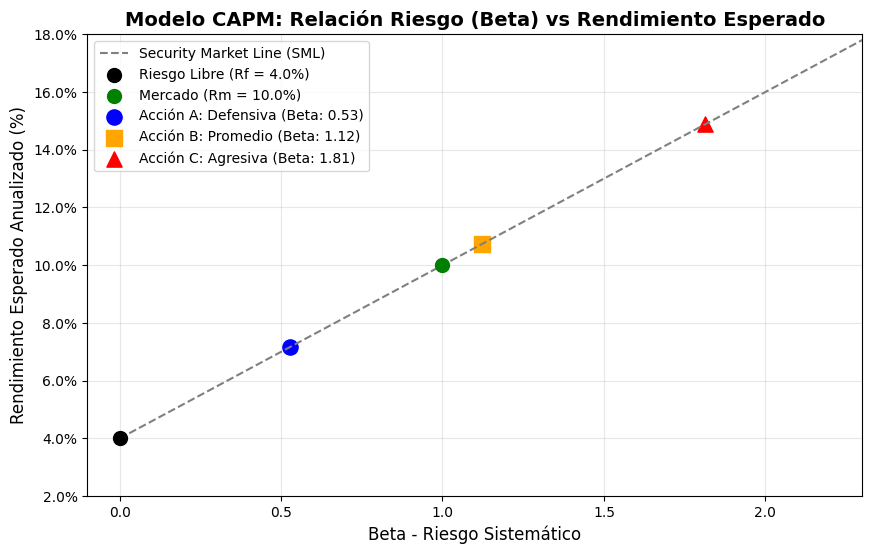

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# 1. Configuración de parámetros básicos (Datos anuales)
np.random.seed(42)
n_dias = 252  # Un año de trading

Rf_anual = 0.04  # 4% Tasa libre de riesgo
Rm_anual = 0.10  # 10% Rendimiento esperado del Mercado

# Convertir parámetros a términos diarios para la simulación
Rf_diario = Rf_anual / n_dias
Rm_diario = Rm_anual / n_dias
volatilidad_mercado = 0.012  # 1.2% de movimiento diario promedio

# 2. Simular los rendimientos diarios del Mercado
rendimientos_mercado = np.random.normal(loc=Rm_diario, scale=volatilidad_mercado, size=n_dias)

# 3. Simular 3 acciones con distintas Betas teóricas
# Acción A (Defensiva, Beta ~ 0.5): Consumo masivo (ej. Walmart)
# Acción B (Mercado, Beta ~ 1.0): Copia al mercado (ej. Un fondo indexado)
# Acción C (Agresiva, Beta ~ 1.8): Tecnología o Cripto (ej. Tesla o Nvidia)

beta_A, beta_B, beta_C = 0.5, 1.0, 1.8
vol_propia = 0.015  # Riesgo idiosincrásico (ruido propio de cada empresa)

rendimientos_A = Rf_diario + beta_A * (rendimientos_mercado - Rf_diario) + np.random.normal(0, vol_propia, n_dias)
rendimientos_B = Rf_diario + beta_B * (rendimientos_mercado - Rf_diario) + np.random.normal(0, vol_propia, n_dias)
rendimientos_C = Rf_diario + beta_C * (rendimientos_mercado - Rf_diario) + np.random.normal(0, vol_propia, n_dias)

# 4. PASO CLAVE: Calcular las Betas reales usando regresión lineal (Capm en la práctica)
# La Beta es la pendiente de la línea cuando cruzas los rendimientos de la acción vs el mercado
beta_calculada_A = linregress(rendimientos_mercado, rendimientos_A).slope
beta_calculada_B = linregress(rendimientos_mercado, rendimientos_B).slope
beta_calculada_C = linregress(rendimientos_mercado, rendimientos_C).slope

# 5. Calcular los Rendimientos Esperados Anualizados según la fórmula CAPM
rend_esperado_A = Rf_anual + beta_calculada_A * (Rm_anual - Rf_anual)
rend_esperado_B = Rf_anual + beta_calculada_B * (Rm_anual - Rf_anual)
rend_esperado_C = Rf_anual + beta_calculada_C * (Rm_anual - Rf_anual)

# ==================== GRAFICACIÓN DE LA SECURITY MARKET LINE (SML) ====================
plt.figure(figsize=(10, 6))

# Dibujar la línea teórica de CAPM (SML)
betas_linea = np.linspace(0, 2.5, 100)
rendimientos_linea = Rf_anual + betas_linea * (Rm_anual - Rf_anual)
plt.plot(betas_linea, rendimientos_linea, color='gray', linestyle='--', label='Security Market Line (SML)')

# Graficar nuestros puntos clave de referencia
plt.scatter(0, Rf_anual, color='black', s=100, zorder=5, label=f'Riesgo Libre (Rf = {Rf_anual*100}%)')
plt.scatter(1, Rm_anual, color='g', s=100, zorder=5, label=f'Mercado (Rm = {Rm_anual*100}%)')

# Graficar las 3 acciones simuladas
plt.scatter(beta_calculada_A, rend_esperado_A, color='blue', s=120, marker='o', label=f'Acción A: Defensiva (Beta: {beta_calculada_A:.2f})')
plt.scatter(beta_calculada_B, rend_esperado_B, color='orange', s=120, marker='s', label=f'Acción B: Promedio (Beta: {beta_calculada_B:.2f})')
plt.scatter(beta_calculada_C, rend_esperado_C, color='red', s=120, marker='^', label=f'Acción C: Agresiva (Beta: {beta_calculada_C:.2f})')

# Personalización del gráfico
plt.title('Modelo CAPM: Relación Riesgo (Beta) vs Rendimiento Esperado', fontsize=14, fontweight='bold')
plt.xlabel('Beta - Riesgo Sistemático', fontsize=12)
plt.ylabel('Rendimiento Esperado Anualizado (%)', fontsize=12)
plt.xlim(-0.1, 2.3)
plt.ylim(0.02, 0.18)
plt.gca().set_yticklabels([f'{x*100:.1f}%' for x in plt.gca().get_yticks()])
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, loc='upper left')

plt.show()
